# How countries use their land? 
_or an overview of 30 biggest countries using OECD Land use dataset presented in a form of artistic petal chart_

A small-multiple of four-petal charts: each country shows how land is split across **arable (cropland)**, **forest**, **meadows and pastures**, and **other**. Petal length is that category's share of those four OECD percentages (renormalized to sum to 1).
> Petal chart is literally a glorified bar chart

* Created in May 2024 
* Refactored and polished with AI agents in September 2026

| Path | Role |
|---|---|
| `data/oecd_land_use_2021.csv` | OECD Environment Database – Land use (2021 slice) |
| `data/README.md` | Sources, SDMX, measure definitions |
| `notebooks/petal_chart/data.py` | Load CSV, pick top-N countries, wide percent table |
| `notebooks/petal_chart/plot.py` | `prepare_canvas`, `plot_petal`, `petal_shares` |
| `notebooks/artifacts/` | Saved PNG charts |


# Table of contents

1. [Import packages](#Import-packages)
1. [Theoretical introduction](#Theoretical-introduction)
    1. [What is a "petal" chart?](#What-is-a-"petal"-chart?)
    1. [How to create a "petal" chart in Python?](#How-to-create-a-"petal"-chart-in-Python?)
    1. [How to create a "petal" chart using our land-use dataset](#How-to-create-a-"petal"-chart-using-our-land-use-dataset)
1. [Get and process land use dataset table](#Get-and-process-land-use-dataset-table)
1. [Charts](#Create-a-chart)
    1. [Top 30](#Top-30)
    1. [Top 50](#Top-50)


# Import packages

In [1]:
import math
import sys
from pathlib import Path

import highlight_text
import itables
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

itables.init_notebook_mode(all_interactive=False)

%matplotlib inline

here = Path.cwd().resolve()
nb_dir = next(
    candidate
    for candidate in (here, *here.parents)
    if (candidate / "petal_chart" / "__init__.py").exists()
)
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))

root = nb_dir.parent  # repo root (shared data/)
from petal_chart import (
    COUNTRY_NAME_REPLACEMENTS,
    MEASURE_ALIASES,
    artifacts_dir,
    land_use_long_to_wide,
    load_oecd_land_use,
    petal_shares,
    plot_petal,
    prepare_canvas,
    get_top_country_names,
)


# Theoretical introduction

## What is a "petal" chart?

> Petal chart is a mix of pie chart with bar chart that uses petal-alike elements and a flower-alike visual style. *(author)*

Inspired by the petal / flower small-multiple tradition:

1. ["Sports City", 2018](https://www.sirvizalot.com/2018/10/sports-city.html) — Matt Chambers
2. ["Petals And Circles Don't Always Make Wreaths", 2021](https://web.archive.org/web/20230202004339/https://cj-mayes.com/2021/04/11/petals-and-circles-dont-always-make-wreaths/) — CJ Mayes
3. ["The Freedom of Expression", 2017](https://www.visualcinnamon.com/portfolio/the-freedom-of-expression/) — Nadieh Bremer

<img src="https://i.imgur.com/lV6XDQ7.png" alt="Petal chart inspiration collage" width="70%">


## How to create a "petal" chart in Python?

Petals are `matplotlib.patches.Ellipse` patches drawn from a shared center. See the [Ellipse gallery](https://matplotlib.org/stable/gallery/shapes_and_collections/ellipse_demo.html).

| Example 1 | Example 2 |
|---|---|
| <img src="https://matplotlib.org/stable/_images/sphx_glr_ellipse_demo_001.png" alt="Matplotlib Ellipse demo 1" width="75%"> | <img src="https://matplotlib.org/stable/_images/sphx_glr_ellipse_demo_002.png" alt="Matplotlib Ellipse demo 2" width="75%"> |

In this notebook the geometry lives in `petal_chart.plot`:

* `prepare_canvas` — circular %-grids, country title, max-category line
* `plot_petal` — one ellipse at a given angle / length
* `petal_shares` — renormalize the four OECD percents so they sum to 1

Four land-use categories → four petals, mid-angles of equal sectors:

`angle = (360 / (n_petals * 2)) * (i * 2 + 1)`


### How to create a "petal" chart using our land-use dataset

The OECD table splits land use into four main categories, so each country gets **four petals**.

* Step-by-step stills: canvas → rays / midpoints → ellipses → finished flower

> <img src="https://i.imgur.com/OaZxbHY.jpeg" alt="Step-by-step petal chart construction (China example)" width="60%">

* Short walkthrough (~20s):


In [2]:
from IPython.display import HTML

HTML("""
<p align="center">
    <video controls muted autoplay loop playsinline loading="lazy"
           alt="HOWTO petal chart, step-by-step (short video)" width="60%">
      <source src="https://i.imgur.com/iiG83iA.mp4" type="video/mp4">
      Your browser does not support the mp4 video tag.
    </video>
</p>
""")


# Get and process land use dataset table

Source notes and OECD definitions: [`data/README.md`](../data/README.md).

Three explicit steps:

1. `load_oecd_land_use` — long OECD CSV  
2. `get_top_country_names` — largest ISO-3 countries by **LAND** km² in `YEAR`  
3. `land_use_long_to_wide` — one wide row per country (`ARABLE` / `FOREST` / `MEAD` / `OTHER` + km²)

Preview uses [itables](https://github.com/mwouts/itables).


In [3]:
# long OECD dump
raw = load_oecd_land_use(root / "data" / "oecd_land_use_2021.csv")
itables.show(raw)

In [4]:
YEAR = 2021
TOP_N = 50  # wide table covers both chart sizes
CATEGORIES = ("ARABLE", "FOREST", "MEAD", "OTHER")
# largest countries by land area (aggregates like "OECD" dropped)
countries = get_top_country_names(raw, year=YEAR, n=TOP_N)

# long → wide: percents + km², short display names, 1-based rank
table = land_use_long_to_wide(
    raw,
    countries=countries,
    year=YEAR,
    categories=CATEGORIES,
    measure_aliases=MEASURE_ALIASES,
    name_replacements=COUNTRY_NAME_REPLACEMENTS,
)
itables.show(table)


# Create a chart

One cell per poster: figure + axes, canvas / petals per country, `highlight_text` title block, save PNG.

## Top 30

Production / preview size.


  0%|          | 0/30 [00:00<?, ?it/s]

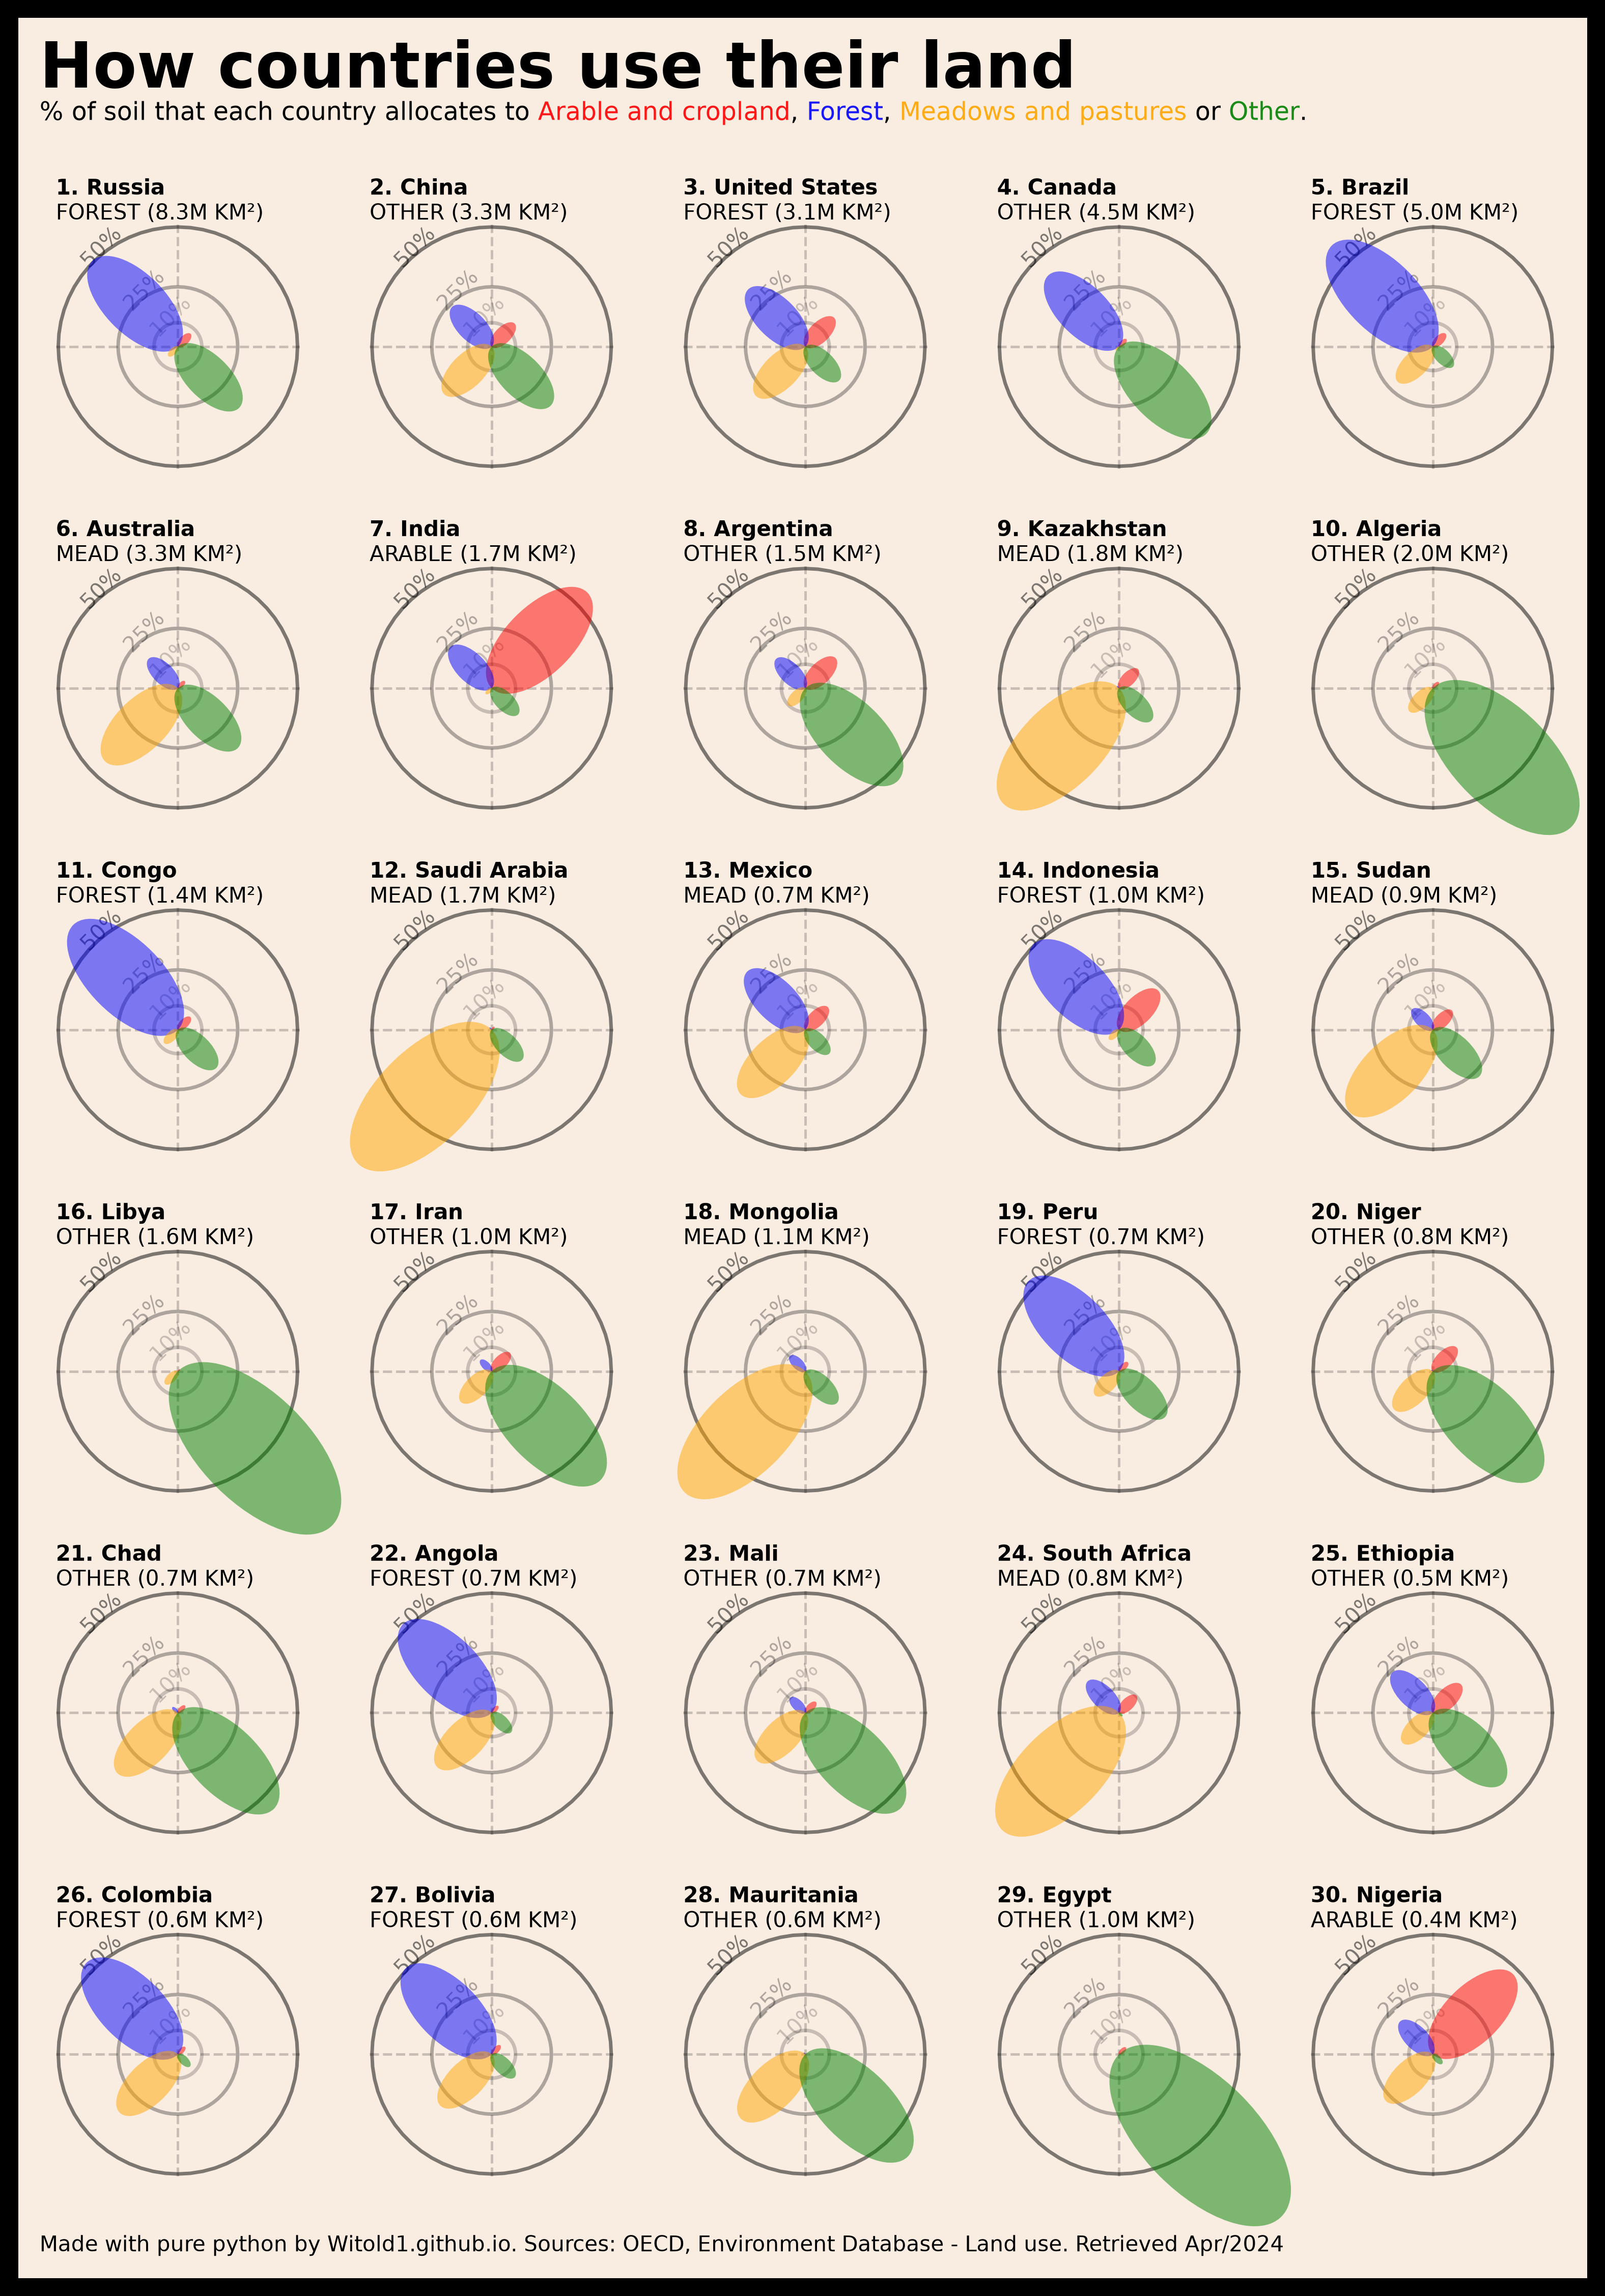

In [5]:
df = table.sort_values("rank").loc[lambda d: d["rank"] <= 30].copy()

# chart / data column order and style (kept in the notebook on purpose)
PETAL_COLORS = ["red", "blue", "orange", "green"]
FACE_COLOR = "#F9EDE2"
n, ncols = len(df), 5
nrows = math.ceil(n / ncols)
fontsize = 6

# figure + axes grid
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6.1, 8.1),
    dpi=500,
    facecolor=FACE_COLOR,
    edgecolor="black",
    linewidth=10,
    subplot_kw=dict(facecolor="none"),
    layout="tight",
)
axes_list = list(axes.flatten())

# canvas + four petals per country (subplot index = rank - 1)
for _, row in tqdm(df.iterrows(), total=n):
    ax = axes_list[int(row["rank"]) - 1]
    shares = petal_shares(row, categories=CATEGORIES)
    max_cat = str(shares.idxmax())

    ax, center = prepare_canvas(
        ax,
        title=f"{int(row['rank'])}. {row['Reference area']}",
        max_category=max_cat,
        max_category_km=float(row[f"{max_cat}_KM"]),
        fontsize=fontsize,
    )
    for indx, (color, value) in enumerate(zip(PETAL_COLORS, shares, strict=True)):
        angle = (360 / (len(PETAL_COLORS) * 2)) * (indx * 2 + 1)
        plot_petal(
            canvas_center=center,
            petal_length=float(value) * 10,
            angle=angle,
            petal_color=color,
            axis=ax,
        )

for ax in axes_list[n:]:
    ax.set_visible(False)

fig.tight_layout(pad=0.15)

# highlight_text needs a canvas with get_renderer (Agg under some notebook backends)
if not hasattr(fig.canvas, "get_renderer"):
    from matplotlib.backends.backend_agg import FigureCanvasAgg

    fig.set_canvas(FigureCanvasAgg(fig))

# title / colored categories / attribution
highlight_text.fig_text(
    fig=fig,
    s="<How countries use their land>",
    x=0.0,
    y=1.055,
    fontsize=round(fontsize * 3),
    highlight_textprops=[{"fontweight": "bold"}],
    horizontalalignment="left",
    va="top",
)
highlight_text.fig_text(
    fig=fig,
    s="% of soil that each country allocates to <Arable and cropland>, <Forest>, <Meadows and pastures> or <Other>.",
    x=0.0,
    y=1.025,
    fontsize=round(fontsize * 1.2),
    highlight_textprops=[{"color": c, "alpha": 0.9} for c in PETAL_COLORS],
    horizontalalignment="left",
    va="top",
)
highlight_text.fig_text(
    fig=fig,
    s="Made with pure python by Witold1.github.io. Sources: OECD, Environment Database - Land use. Retrieved Apr/2024",
    x=0.0,
    y=-0.010,
    fontsize=round(fontsize),
    horizontalalignment="left",
    va="top",
)

out = artifacts_dir() / "land_use_top30.png"
fig.savefig(out, bbox_inches="tight", format="png")


## Top 50

Same chart, taller figure for fifty countries.

  0%|          | 0/50 [00:00<?, ?it/s]

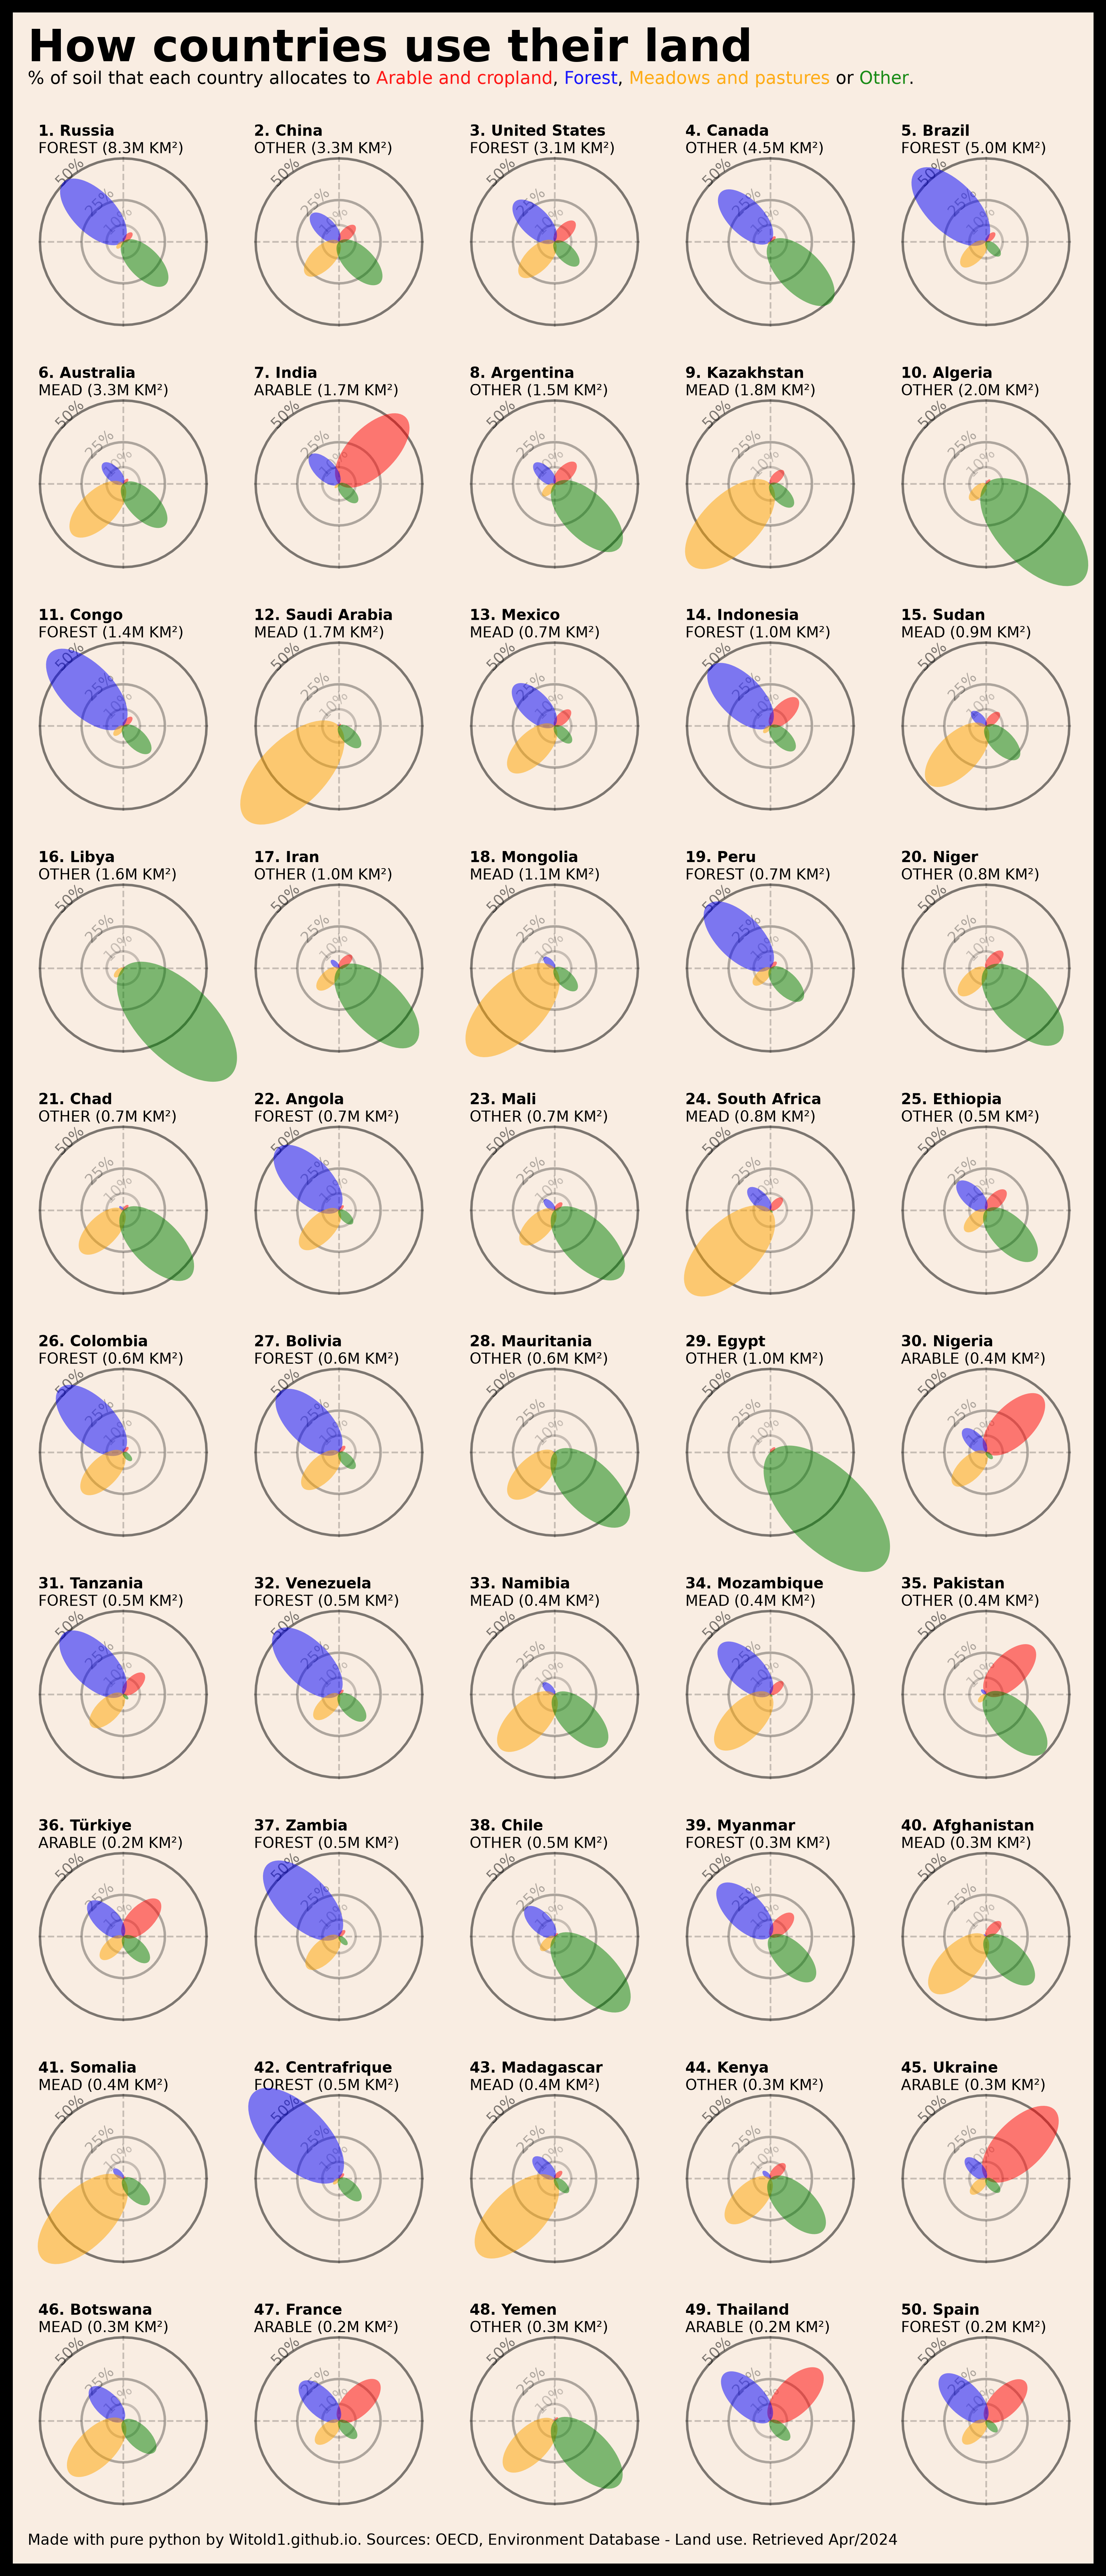

In [6]:
df = table.sort_values("rank").loc[lambda d: d["rank"] <= 50].copy()

PETAL_COLORS = ["red", "blue", "orange", "green"]
FACE_COLOR = "#F9EDE2"
n, ncols = len(df), 5
nrows = math.ceil(n / ncols)
fontsize = 6

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6.0, 13.5),
    dpi=500,
    facecolor=FACE_COLOR,
    edgecolor="black",
    linewidth=10,
    subplot_kw=dict(facecolor="none"),
    layout="tight",
)
axes_list = list(axes.flatten())

for _, row in tqdm(df.iterrows(), total=n):
    ax = axes_list[int(row["rank"]) - 1]
    shares = petal_shares(row, categories=CATEGORIES)
    max_cat = str(shares.idxmax())

    ax, center = prepare_canvas(
        ax,
        title=f"{int(row['rank'])}. {row['Reference area']}",
        max_category=max_cat,
        max_category_km=float(row[f"{max_cat}_KM"]),
        fontsize=fontsize,
    )
    for indx, (color, value) in enumerate(zip(PETAL_COLORS, shares, strict=True)):
        angle = (360 / (len(PETAL_COLORS) * 2)) * (indx * 2 + 1)
        plot_petal(
            canvas_center=center,
            petal_length=float(value) * 10,
            angle=angle,
            petal_color=color,
            axis=ax,
        )

for ax in axes_list[n:]:
    ax.set_visible(False)

fig.tight_layout(pad=0.15)

if not hasattr(fig.canvas, "get_renderer"):
    from matplotlib.backends.backend_agg import FigureCanvasAgg

    fig.set_canvas(FigureCanvasAgg(fig))

highlight_text.fig_text(
    fig=fig,
    s="<How countries use their land>",
    x=0.0,
    y=1.033,
    fontsize=round(fontsize * 3),
    highlight_textprops=[{"fontweight": "bold"}],
    horizontalalignment="left",
    va="top",
)
highlight_text.fig_text(
    fig=fig,
    s="% of soil that each country allocates to <Arable and cropland>, <Forest>, <Meadows and pastures> or <Other>.",
    x=0.0,
    y=1.015,
    fontsize=round(fontsize * 1.2),
    highlight_textprops=[{"color": c, "alpha": 0.9} for c in PETAL_COLORS],
    horizontalalignment="left",
    va="top",
)
highlight_text.fig_text(
    fig=fig,
    s="Made with pure python by Witold1.github.io. Sources: OECD, Environment Database - Land use. Retrieved Apr/2024",
    x=0.0,
    y=-0.010,
    fontsize=round(fontsize),
    horizontalalignment="left",
    va="top",
)

out = artifacts_dir() / "land_use_top50.png"
fig.savefig(out, bbox_inches="tight", format="png")


Author: [Witold1](https://witold1.github.io).